In [1]:
from models.analyzer import FeatureSelectionAnalyzer

In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [3]:
data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

In [4]:
data.dropna(subset=['Смерть'], inplace=True)
data['Смерть'] = data['Смерть'].map({'Да': 1, 'Нет': 0})

In [5]:
cols = [
    "Смерть",
    "Age",
    "Sex",
    "Рост",
    "Вес",
    "Индекс массы тела", 
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "ОНМК (гем) в анамнезе",
    "Стентирование в анамнезе",
    "Открытая перация на сердце в анамнезе",
    "ГБ стадия",
    "ГБ риск",
    "АГ",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "ЖКБ",
    "ХОБЛ (Новый столбец)",
    "Курит",
    "Экстракардиальная артериопатия",
    "Плохая мобильность",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "Стенокардия ФК (ИБ)",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Форма ФП",
    "ФП постоянная форма",
    "ФП при окс (до чкв)", 
    "ЧКВ",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "Количество пораженных сосудов(Syntax)",
    "Количество пораженных сосудов(Значимость)",
    "TIMI",
    "Класс ОСН по Killip",
    "ХСН стадия",
    "ФЖ",
    "Пробежки ЖТ",
    "Рецидивирующая ЖТ",
    "Срочность",
    "Экстренная операция(ИБ)(Новый)",
    "Вид операции(ИБ)(Новый)",
    "Тромболизис",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "А-В блокада",
    "А-В блокада (степень)",
]

In [6]:
category_cols = [
    "Sex", "STEMI", "ЧКВ", "Вид STEMI", "Инфаркт-зависимая артерия",
    "Поражение ствола","Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",'Инфаркт миокарда со стентированием в анамнезе',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе','Стентирование в анамнезе',
    'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий','ФП b (после чкв)',
    'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ',
    'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip',
    'ХСН стадия', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)',
    'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'Стеноз аортального клапана (степень)',
    'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)', 'повторные операции','Тип первой операции БД',
    'Тип повторной операции', 'GRACE(Общее)>140', 'интегрилин|эптифибатид|коромакс|агграстат',
    'Экстракардиальная артериопатия', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе',
    'Срочность', 'Сопутствующие1', 'Сопутствующие2', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 > 0.1 (a)',
    'Тропонин 1 > 0.1', 'Smoking', 'Протокол коронарографии', 'Аортальный стеноз (Градиент)',
    'Аортальный стеноз (Заключение)', 'ХОБЛ (Новый столбец)', 'Коррекция А-В блокады',
    'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)', 'А-В блокада',
    'Стенокардия в диагнозе при поступлении', 'ПИКС в диагнозе при поступлении',
    'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)', 'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)', 'Курит', 'GRACE(Общее)>156', 'Отек легких(b)',
    'Отек легких(a)', 'Отек легких', 'Медицинская помощь оказана за первые 4 часа',
    'Гипертоническая болезнь', 'ФВ < 40', 'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)', 'А-В блокаДа (Новый)', 'А-В блокада (степень)',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'ИВЛ', 'Вазопрессорная поддержка', 'Адреналин',
    'Добутамин', 'Допмин', 'Норадреналин', 'Левосимендан',
    'Мезатон', 'UA (нестабильная стенокардия)','Синдромный диагноз','Смерть'
]

In [7]:
cols_to_delete = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок",
    'длительность нахождения в стационаре',
    'GRACE(Общее)>140',
    'GRACE(Общее)>156',
    'Отек легких(b)',
    'Отек легких(a)', 'Отек легких',
    'CADILLAC (Низкий риск)', 'CADILLAC (Средний риск)',
    'CADILLAC (Высокий риск)', 'РЕКОРД (Низкий риск)', 'РЕКОРД (Высокий риск)',
    'GRACE (Низкий риск)', 'GRACE (Средний риск)', 'GRACE (Высокий риск)',
    'TIMI (Летальность) (Низкий риск)', 'TIMI (Летальность) (Средний риск)',
    'TIMI (Летальность) (Высокий риск)', 'PAMI (Низкий риск)', 'PAMI (Средний риск)',
    'PAMI (Высокий риск)',
    'МКБ', 'ЖКБ',
    'Протокол коронарографии',
    'Класс ОСН по Killip',
    'ФВ < 40',
    "Мочевина(a)",
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более',
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    "TIMI",
    "GRACE(Общее)",
    "GRACE(Общее)>140",
    "GRACE(Общее)>156",
    "TIMI (Летальность)",
    "GRACE (Низкий риск)",
    "GRACE (Средний риск)",
    "GRACE (Высокий риск)",
    "TIMI (Летальность) (Низкий риск)",
    "TIMI (Летальность) (Средний риск)",
    "TIMI (Летальность) (Высокий риск)",
    "Дата и время развития SOFA 8 и более",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Часов в ОРИТ ПОСЛЕ развития SOFA 8",
    "Максимальный прокальцитонин за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки до развития SOFA 8",
    "Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8",
    "Максимальный ЛАКТАТ вена за сутки после развития SOFA 8",
    "SOFA первый раз больше или равна 8 баллам",
    "SOFA до развития 8 и более баллов",
    "Используемый антибиотик ДО развития SOFA 8 и более",
    "Левофлоксацин антибиотик ДО развития SOFA 8 и более",
    "Линезолид антибиотик ДО развития SOFA 8 и более",
    "Меропенем антибиотик ДО развития SOFA 8 и более",
    "Метронидазол антибиотик ДО развития SOFA 8 и более",
    "Моксифлоксацин антибиотик ДО развития SOFA 8 и более",
    "Нифуроксазид антибиотик ДО развития SOFA 8 и более",
    "Фосфомицин антибиотик ДО развития SOFA 8 и более",
    "Цефазолин антибиотик ДО развития SOFA 8 и более",
    "Сульбактам антибиотик ДО развития SOFA 8 и более",
    "Цефоперазон антибиотик ДО развития SOFA 8 и более",
    "Цефтриаксон антибиотик ДО развития SOFA 8 и более",
    "Количество часов применения антибиотика ДО развития SOFA 8 и более",
    "Антибиотик после развития SOFA 8 и более",
    "Моксифлоксацин после развития SOFA 8 и более",
    "Левофлоксацин после развития SOFA 8 и более",
    "Азитромицин после развития SOFA 8 и более",
    "Линезолид после развития SOFA 8 и более",
    "Меропенем после развития SOFA 8 и более",
    "Метронидазол после развития SOFA 8 и более",
    "Нифуроксазид после развития SOFA 8 и более",
    "Фосфомицин после развития SOFA 8 и более",
    "Цефазолин после развития SOFA 8 и более",
    "Сульбактам после развития SOFA 8 и более",
    "Цефепим после развития SOFA 8 и более",
    "Цефтриаксон после развития SOFA 8 и более",
    "Через сколько часов после развития SOFA 8 и более был введен антибиотик",
    "APACHE сутки до развития SOFA 8 и более",
    "APACHE сутки ПОСЛЕ развития SOFA 8 и более",
    "АД среднее за сутки до развития SOFA 8",
    "Среднее АД 1 сутки в орит",
    "Среднее АД 3 сутки в орит",
    "Среднее АД 7 сутки в орит",
    "Среднее ЧСС 1 сутки",
    "Среднее ЧСС 3 сутки",
    "Среднее ЧСС 7 сутки",
    "Экстренная операция(ИБ)(Новый)",
    "ИВЛ",
    "Количество дней в реанимации",
    "Часов до введения первого антибиотика",
    "Часов в ОРИТ ДО развития SOFA 8",
    "Apache II",
    "TIMI Летальность",
    "Количество пораженных сосудов Syntax", 
    "Поражение ствола", 
    "Инфаркт-зависимая артерия",
    "Вазопрессорная поддержка",
    "Адреналин",
    "Добутамин",
    "Норадреналин",
    "Левосимендан",
    "Макс АД 1 сут",
    "Мин ЧСС 7 сутки",
    "Макс АД 7 сут",
    "CADILLAC",
    "PAMI",
    "РЕКОРД", 
    "Инфаркт-зависимая артерия Огригированная",
    "СДЛА",
    "killip",
    "повторные операции",
    "Вид операции(ИБ)(Новый)",
    "Срочность",
    "Тип повторной операции",
    "Тип первой операции БД",
    "Тип повторной операции",
]

In [8]:
for col in cols_to_delete:
    try:
        data.drop([col], axis=1, inplace=True)
    except Exception as e: 
        print(col, e)

        for i in data.columns:
            if col in i:
                print("Found ", col, i)


GRACE(Общее)>140 "['GRACE(Общее)>140'] not found in axis"
GRACE(Общее)>156 "['GRACE(Общее)>156'] not found in axis"
GRACE (Низкий риск) "['GRACE (Низкий риск)'] not found in axis"
GRACE (Средний риск) "['GRACE (Средний риск)'] not found in axis"
GRACE (Высокий риск) "['GRACE (Высокий риск)'] not found in axis"
TIMI (Летальность) (Низкий риск) "['TIMI (Летальность) (Низкий риск)'] not found in axis"
TIMI (Летальность) (Средний риск) "['TIMI (Летальность) (Средний риск)'] not found in axis"
TIMI (Летальность) (Высокий риск) "['TIMI (Летальность) (Высокий риск)'] not found in axis"
Дата и время развития SOFA 8 и более "['Дата и время развития SOFA 8 и более'] not found in axis"
Используемый антибиотик ДО развития SOFA 8 и более "['Используемый антибиотик ДО развития SOFA 8 и более'] not found in axis"
Левофлоксацин антибиотик ДО развития SOFA 8 и более "['Левофлоксацин антибиотик ДО развития SOFA 8 и более'] not found in axis"
Линезолид антибиотик ДО развития SOFA 8 и более "['Линезолид а

In [10]:
col_names = data.columns 
for col in col_names:
    try:
        if "(a)" in col or "(а)" in col:
            data.drop([col], axis=1, inplace=True)
        if " сут" in col or " сутки" in col:
            data.drop([col], axis=1, inplace=True)
        if "min" in col or "Min" in col or "max" in col or "Max" in col:
            data.drop([col], axis=1, inplace=True)
    except Exception as e:
        print(e)

"['pHARTmax (a)'] not found in axis"
"['pO2ARTmin (a)'] not found in axis"
"['pO2ARTmax (a)'] not found in axis"
"['pCO2min (a)'] not found in axis"
"['pCO2max (a)'] not found in axis"
"['SaO2min (a)'] not found in axis"
"['SaO2max (a)'] not found in axis"
"['LACTartMin (a)'] not found in axis"
"['LACTartMax (a)'] not found in axis"
"['BEArtMin (a)'] not found in axis"
"['BEArtMax (a)'] not found in axis"
"['HCO3ArtMin (a)'] not found in axis"
"['HCO3ArtMax (a)'] not found in axis"
"['PHVenMin (a)'] not found in axis"
"['PHVenMax (a)'] not found in axis"
"['PO2VenMin (a)'] not found in axis"
"['PO2VenMax (a)'] not found in axis"
"['PCO2VenMin (a)'] not found in axis"
"['PCO2VenMax (a)'] not found in axis"
"['ScvO2Min (a)'] not found in axis"
"['ScvO2Max (a)'] not found in axis"
"['LactVenMin (a)'] not found in axis"
"['LactVenMax (a)'] not found in axis"
"['BEVenMin (a)'] not found in axis"
"['BEVenMax (a)'] not found in axis"
"['HCO3VenMin (a)'] not found in axis"
"['HCO3VenMax (a)'] 

In [11]:
data

,Age,Sex,STEMI,ЧКВ,Вид STEMI,Количество пораженных сосудов(Syntax),Количество пораженных сосудов(Значимость),Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,ОНМК (гем) в анамнезе,Стентирование в анамнезе,Тромболизис,Форма ФП,Калий,Дилатация предсердий,ФП b (после чкв),ФП a (в анамнезе),ФП при окс (до чкв),ФП постоянная форма,ФЖ,Пробежки ЖТ,Рецидивирующая ЖТ,MKB,ХСН стадия,ГБ стадия,ГБ риск,АГ,Стенокардия (ИБ),Стенокардия форма(ИБ),Стенокардия ФК (ИБ),СД,ХБП,ЯБ,ФВ ЛЖ (b),ФВ ЛЖ,EDV,МЖП,ЗСЛЖ,ПСПЖ,Размер правого желудочка,Стеноз аортального клапана (степень),Недостаточность аортального клапана (степень),Стеноз митрального клапана (степень),Недостаточность митрального клапана (степень),Недостаточность трикуспидального клапана (степень),НПВ,НПВ диаметр,La1,La2,Ra1,Ra2,Гематокрит,Гемоглобин,Эритроциты,Лейкоциты,Тромбоциты,Нейтрофилы (абсолютное значение),Нейтрофилы (относительное значение),Лимфоциты (абсолютное значение),Лимфоциты (относительное значение),Моноциты (абсолютное значение),Моноциты (относительное значение),Эозинофилы (абсолютное значение),Эозинофилы (относительное значение),Базофилы (абсолютное значение),Базофилы (относительное значение),Сумма всех лейкоцитов,Средний объем эритроцита,Среднее содержание гемоглобина в эритроците,"Ср, концентрация гемоглобина в эритроците",Распределение эритроцитов по объему (RDW-CV),Распределение эритроцитов по объему (RDW-SD),Средний объем тромбоцита (MPV),Расчетная ширина распределения тромбоцитов,Тромбокрит,Коэффициент крупных тромбоцитов,СОЭ,С-реактивный белок,PLR (тромбоциты/лимфоциты абс) (61-239),MLR (моноциты/лимфоциты),LMR (лимфоциты абс/моноциты абс),SII (тромбоциты*нейтрофилы абс / лимфоциты абс),ELR (эозинофилы абс/лимфоциты абс,ELR %,ENR (эозин абс/нейтрофилы абс),BLR (базофилы абс/лимфоциты абс),SIRI (NxM)/L,PIV or AISI (NxMxPLT)/L,GLR (глюкоза мг/дл / лимф абс),FLR (fibr/L abs),RLR (RDW/ lymph abs),MPV/PC (MPV/ PLT),Глюкоза в мг/дл,Фибриноген,Эозинофилы(%)(b),Палочкоядерные нейтрофилы(%)(b),Cегментоядерные нейтрофилы(%)(b),Лимфоциты(%)(b),Моноциты(%)(b),Общий белок(b),Глюкоза(b),АСАТ(b),АЛАТ(b),Билирубин общий(b),Холестерин общий(b),Триглицериды(b),Креатинин(b),Мочевина(b),ЛДГ(b),КФК(b),КФК-МВ(b),ПТИ(b),МНО(b),ТВ(b),АПТВ(b),Продолжительность операции,Смерть,интегрилин|эптифибатид|коромакс|агграстат,Рост,Вес,Индекс массы тела,Экстракардиальная артериопатия,Плохая мобильность,Открытая перация на сердце в анамнезе,Систолическое АД(b),Диастолического АД(b),ЧСС (b),P,PQ,QRS,QT,RR,Сопутствующие1,Сопутствующие2,Креатинин,СКФ,Тропонин 1 (b),Тропонин 1 > 0.1 (b),Тропонин 1,Тропонин 1 > 0.1,Smoking,Аортальный стеноз (Градиент),Аортальный стеноз (Заключение),ХОБЛ (Новый столбец),Коррекция А-В блокады,Исход А-В блокады,Начало А-В блокады (До/после ЧКВ),А-В блокада,Стенокардия в диагнозе при поступлении,ПИКС в диагнозе при поступлении,Инфаркт-зависимая артерия(Огригированная),Инфаркт-зависимая артерия(Огригированная)2,Ишемический инсульт (Выгрузка из ИБ - временный столбец),Геморрагический инсульт (Выгрузка из ИБ - временный столбец),Инсульт (Выгрузка из ИБ - временный столбец),SpO2,Курит,Медицинская помощь оказана за первые 4 часа,Гипертоническая болезнь,Время ЧКВ,А-В блокаДа (Новый),А-В блокада (степень),Лейкоциты больше 9 до назначения аб,Допмин,Мезатон,UA (нестабильная стенокардия),Синдромный диагноз,Натрий (Na) (b),Калий (K) (b),Хлор (Cl) (b),Кальций ионизированный (Ca+) (b),Натрий (Na),Калий (K),Хлор (Cl),Кальций ионизированный (Ca+),BNP (b),BNP
0,78.0,М,Нет,Да,NaN,2.0,2.0,Нет,Нет,Нет,Нет,NaN,NaN,Да,NaN,NaN,NaN,Нет,Нет,NaN,NaN,NaN,NaN,NaN,I21.1,NaN,3.0,4.0,NaN,Нет,NaN,NaN,Нет,Нет,NaN,NaN,57.0,NaN,1.0,1.1,0.35,2.2,0,NaN,NaN,NaN,NaN,NaN,1.5,4.0,6.0,4.0,5.1,NaN,144.0,5.00,8.36,178.0,4.40,52.6,2.84,34.0,0.86,10.3,2.80,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [12]:
for col in category_cols:
    if col not in cols_to_delete:
        try:
            data[col] = data[col].fillna('missing').astype('str')
            data[col] = data[col].astype('category')
        except Exception:
            pass

In [13]:
X = data.drop(["Смерть"], axis=1)
y = data["Смерть"].astype('int')

In [14]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [15]:
cat_features = []
for col in X_clean.columns:
    try:
        if X_clean[col].dtype.name == 'category': 
            cat_features.append(col)
    except Exception as e:
        print(col)

In [16]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [17]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [18]:
scale_pos_weight = len(y[y == 0]) / max(1, len(y[y == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

print(f"scale pos weight: {scale_pos_weight}")

scale pos weight: 27.89217391304348


In [19]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    # early_stopping_rounds=50  # задается при инициализации
)

cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50,  # задается при инициализации
    # cat_features=list(X.select_dtypes(include=['category']).columns)
)

In [20]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(cat_model, max_features=None, metric='roc_auc')

=== FORWARD SELECTION ===
Запуск Forward Selection...


  0%|          | 0/178 [00:00<?, ?it/s]

  1%|          | 1/178 [00:19<56:38, 19.20s/it, roc_auc=0.7994, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7994


  1%|          | 2/178 [00:40<1:00:34, 20.65s/it, roc_auc=0.8630, Features=2]

...

Step 5: Добавлен признак 'Аортальный_стеноз_Градиент', roc_auc: 0.9357


  3%|▎         | 6/178 [02:31<1:17:14, 26.95s/it, roc_auc=0.9411, Features=6]

Step 6: Добавлен признак 'ФП_при_окс_до_чкв', roc_auc: 0.9411


  3%|▎         | 6/178 [03:01<1:26:48, 30.28s/it, roc_auc=0.9411, Features=6]

Step 7: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 6


In [31]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(cat_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  0%|          | 1/242 [04:08<16:39:16, 248.78s/it, roc_auc=0.9583, Features=242]

Step 1: Удален признак 'Тип_повторной_операции', roc_auc: 0.9583


  1%|          | 2/242 [08:16<16:32:52, 248.22s/it, roc_auc=0.9610, Features=241]

Step 2: Удален признак 'Моноциты_абсолютное_значение', roc_auc: 0.9610


  1%|          | 2/242 [12:22<24:44:31, 371.13s/it, roc_auc=0.9610, Features=241]

Step 3: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 241



=== СРАВНЕНИЕ МЕТОДОВ ===


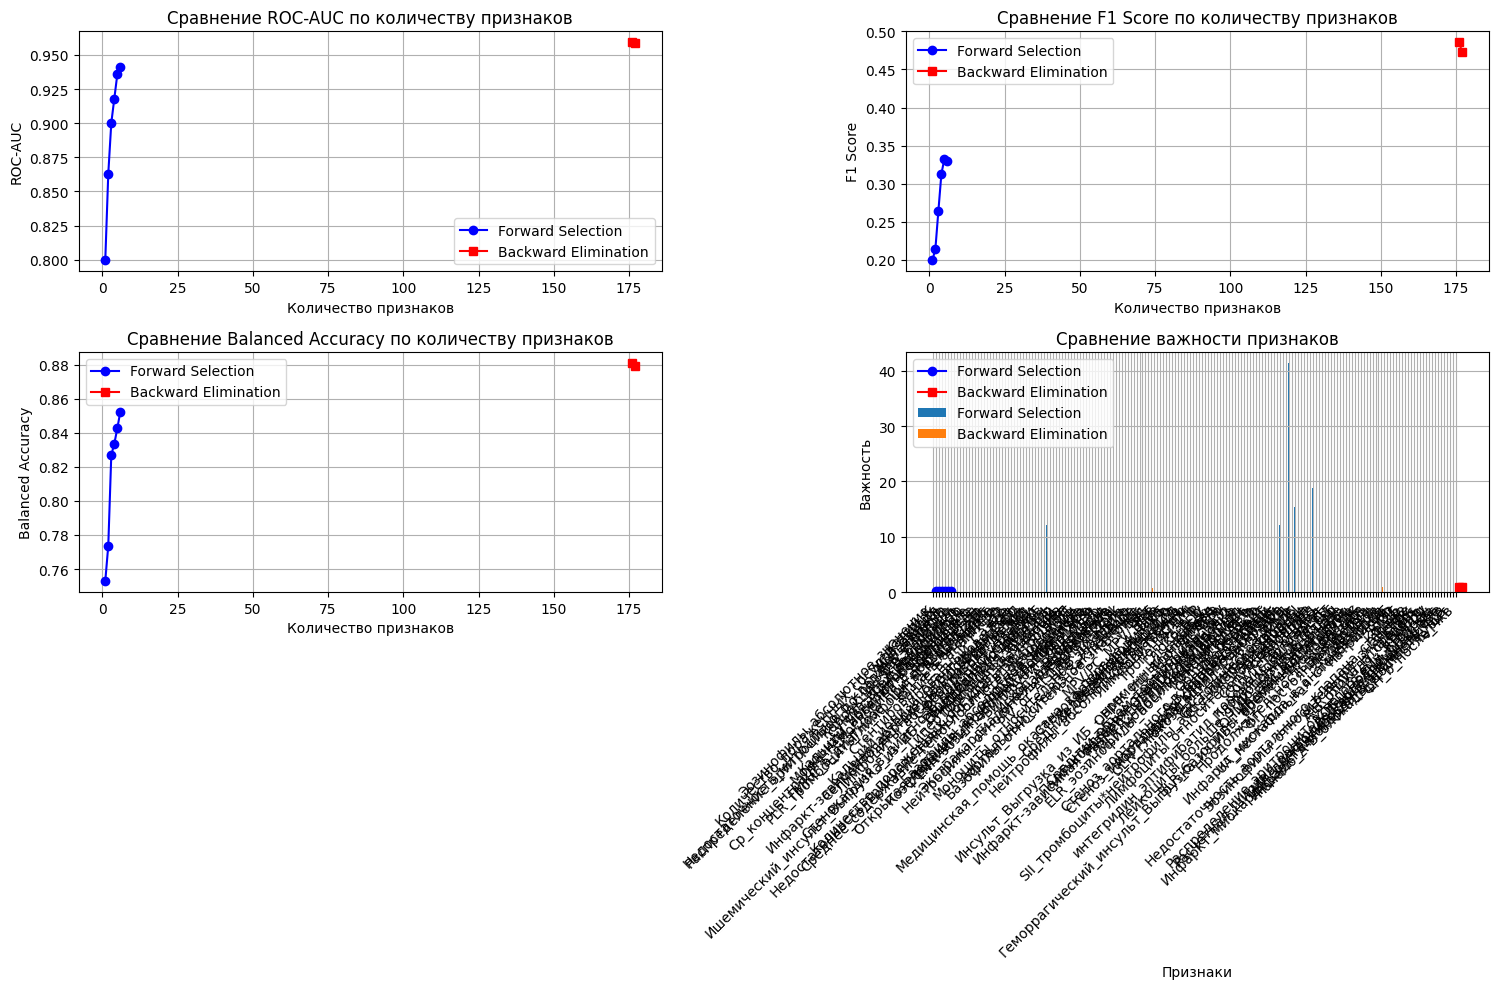

In [22]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [23]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 6 признаков) ===
Лучший Threshold: 0.8500 (F1=0.5311)
По Youden's J: 0.6565


In [24]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 176 признаков) ===
Лучший Threshold: 0.8300 (F1=0.6234)
По Youden's J: 0.2432



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


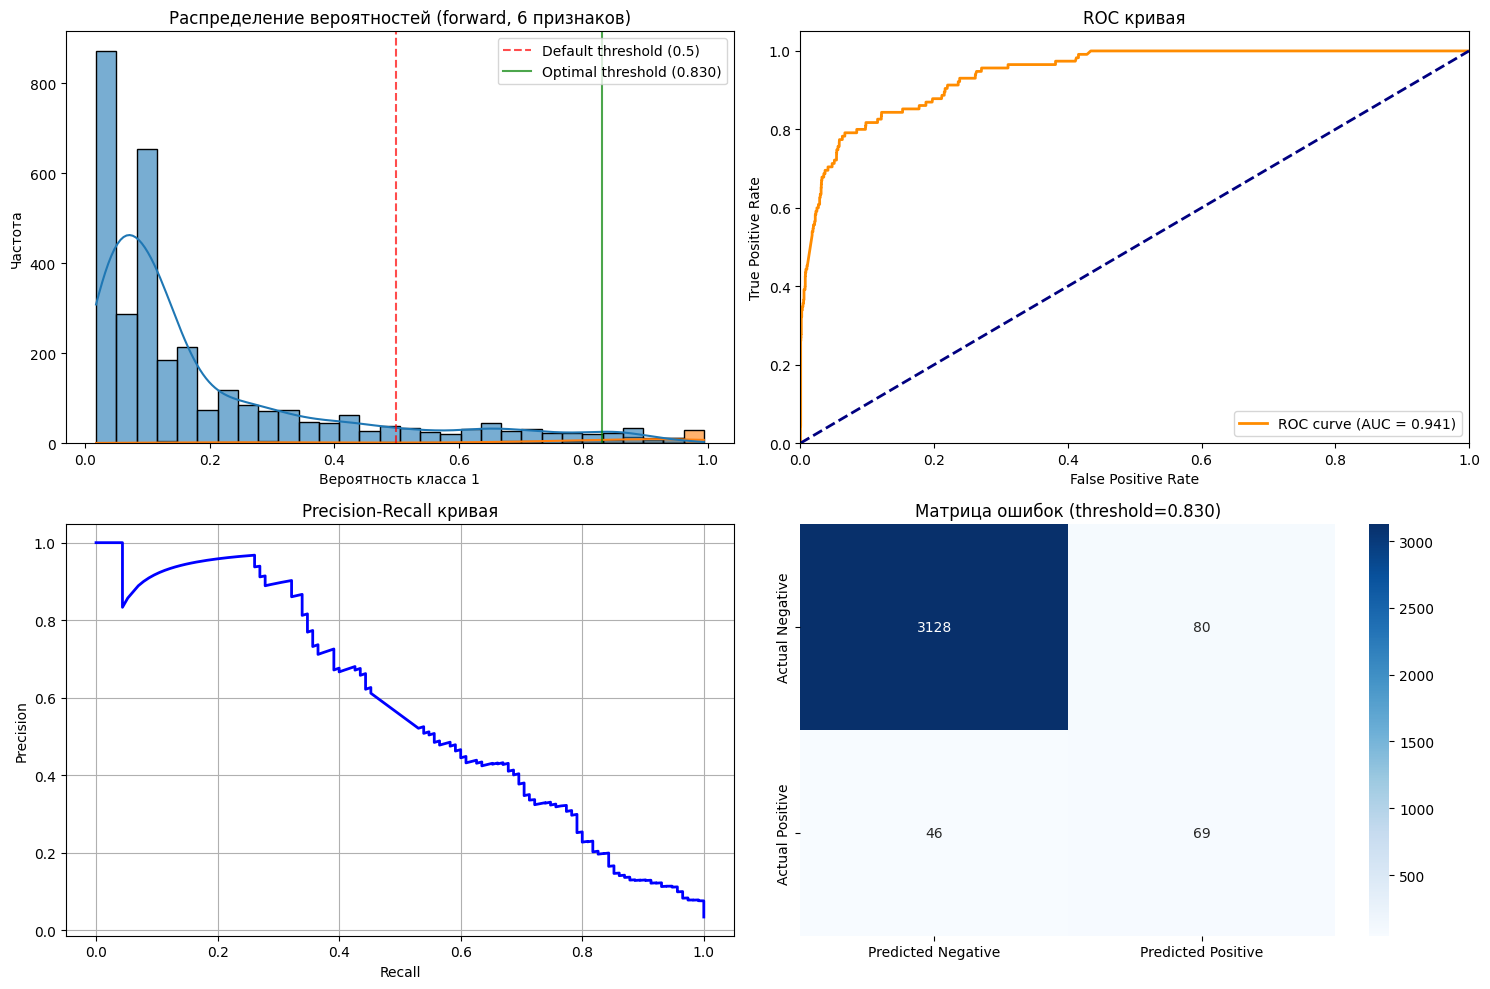

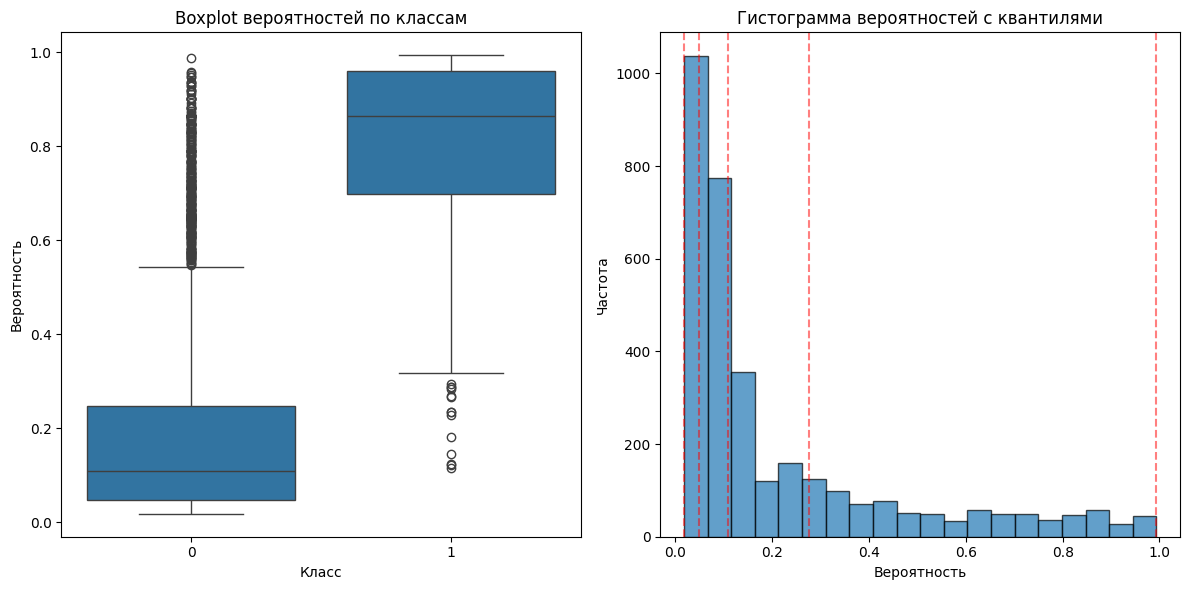

In [25]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


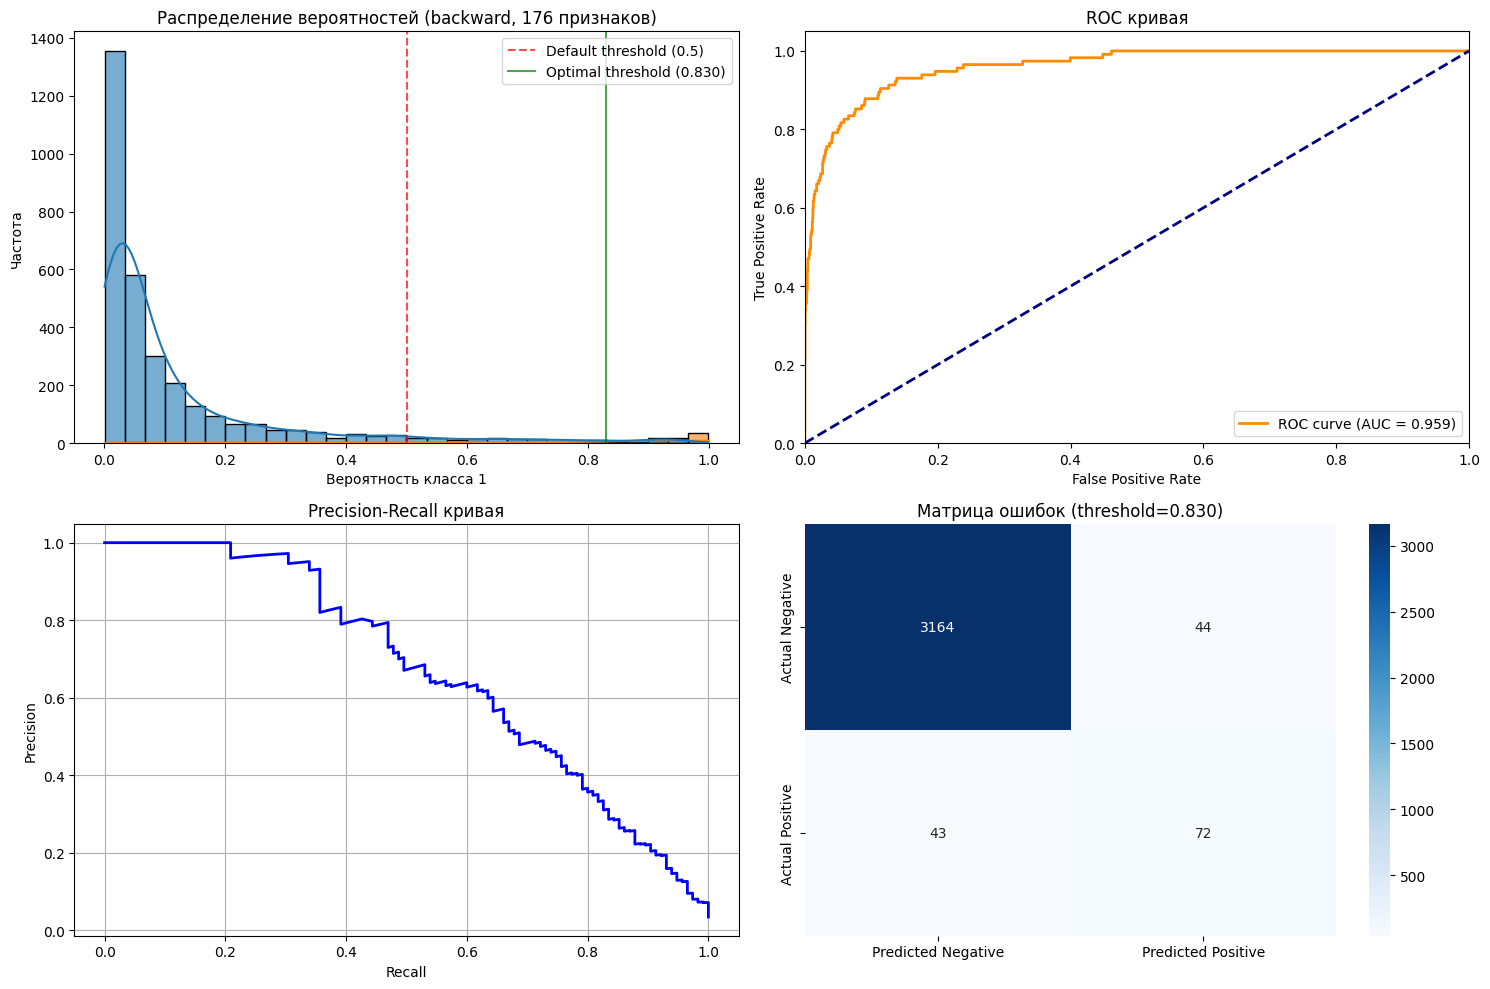

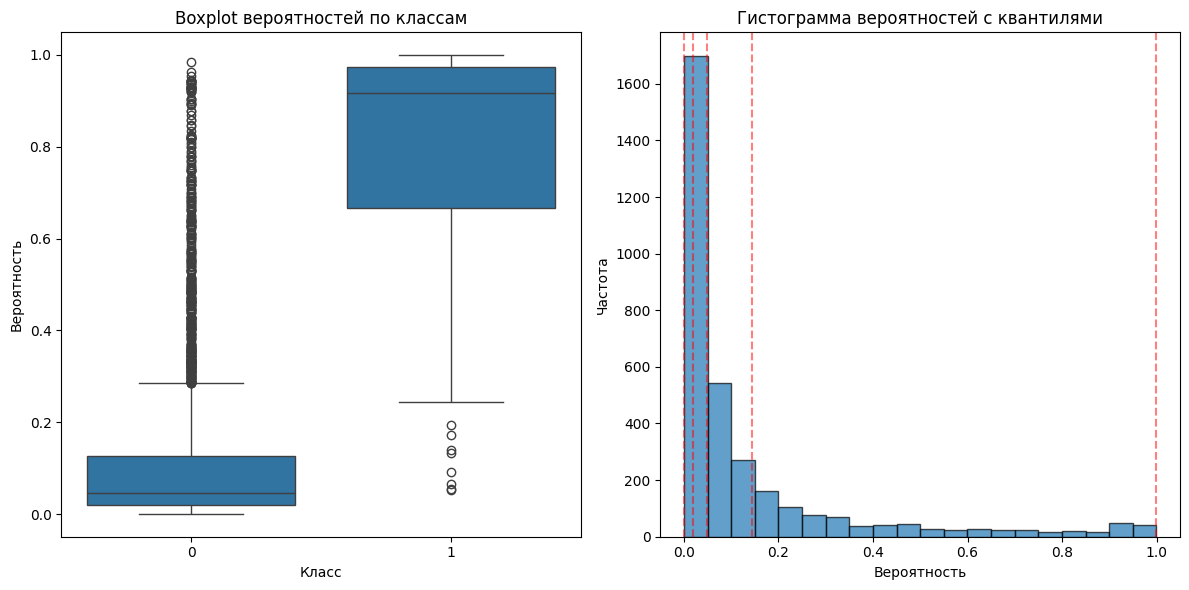

In [26]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [27]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 5
Лучшая f1: 0.3327
Признаки: ['Креатинин', 'MKB', 'Синдромный_диагноз', 'Систолическое_АД_b', 'Аортальный_стеноз_Градиент']

Важность признаков:
  MKB: 41.3550
  Креатинин: 18.8867
  Систолическое_АД_b: 15.4470
  Аортальный_стеноз_Градиент: 12.1911
  Синдромный_диагноз: 12.1202
=== Лучшие признаки (backward) ===
Количество признаков: 176
Лучшая f1: 0.4858
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимость', 'Инфаркт_миокарда_в_анамнезе_lt_3', 'Инфаркт_миокарда_в_анамнезе_gt_3', 'Инфаркт_миокарда_со_стентированием_в_анамнезе', 'ОНМК_иш_в_анамнезе', 'ОНМК_гем_в_анамнезе', 'Стентирование_в_анамнезе', 'Тромболизис', 'Форма_ФП', 'Калий', 'Дилатация_предсердий', 'ФП_b_после_чкв', 'ФП_a_в_анамнезе', 'ФП_при_окс_до_чкв', 'ФП_постоянная_форма', 'ФЖ', 'Рецидивирующая_ЖТ', 'MKB', 'ХСН_стадия', 'ГБ_стадия', 'ГБ_рис

In [28]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9357 с 5 признаками
Лучший ROC AUC (Backward): 0.9593 с 176 признаками
Оптимальный порог для бинарной классификации: 0.8300


-----------------

In [29]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [30]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(xgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  1%|          | 1/178 [00:09<29:21,  9.95s/it, roc_auc=0.7900, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7900


  1%|          | 2/178 [00:22<34:09, 11.64s/it, roc_auc=0.8499, Features=2]

Step 2: Добавлен признак 'UA_нестабильная_стенокардия', roc_auc: 0.8499


...

Step 13: Добавлен признак 'Лейкоциты', roc_auc: 0.9560


  8%|▊         | 14/178 [04:01<57:52, 21.17s/it, roc_auc=0.9574, Features=14]

Step 14: Добавлен признак 'Гипертоническая_болезнь', roc_auc: 0.9574


  8%|▊         | 14/178 [04:22<51:17, 18.77s/it, roc_auc=0.9574, Features=14]

Step 15: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 14


In [31]:
print("\n=== BACKWARD ELIMINATION ===")
backward_features = analyzer.backward_elimination(xgb_model, min_features=1, metric='roc_auc')


=== BACKWARD ELIMINATION ===
Запуск Backward Elimination...


  1%|          | 1/177 [02:01<5:55:32, 121.21s/it, roc_auc=0.9569, Features=177]

Step 1: Удален признак 'ФВ_ЛЖ_b', roc_auc: 0.9569


  1%|          | 2/177 [04:00<5:49:43, 119.91s/it, roc_auc=0.9581, Features=176]

Step 2: Удален признак 'Сопутствующие2', roc_auc: 0.9581


...

Step 5: Удален признак 'ОНМК_иш_в_анамнезе', roc_auc: 0.9613


  3%|▎         | 6/177 [11:46<5:32:07, 116.54s/it, roc_auc=0.9613, Features=172]

Step 6: Удален признак 'Курит', roc_auc: 0.9613


  3%|▎         | 6/177 [13:41<6:30:04, 136.87s/it, roc_auc=0.9613, Features=172]

Step 7: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 172


In [43]:
1

1


=== СРАВНЕНИЕ МЕТОДОВ ===


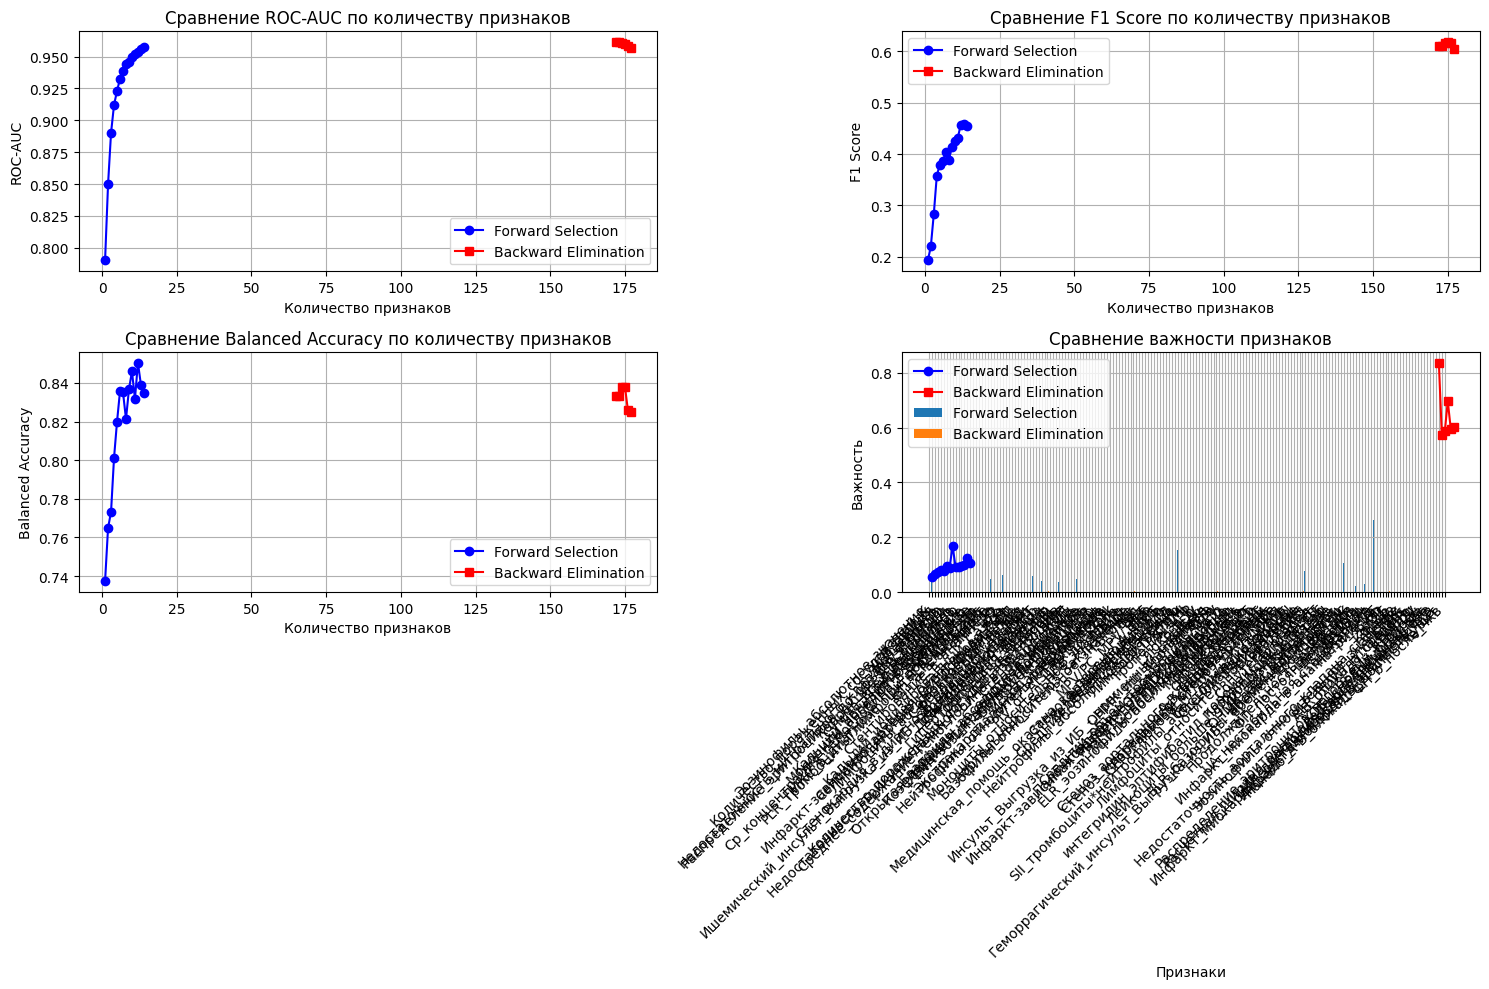

In [32]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [33]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 14 признаков) ===
Лучший Threshold: 0.8900 (F1=0.5856)
По Youden's J: 0.2077


In [34]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 172 признаков) ===
Лучший Threshold: 0.6300 (F1=0.6245)
По Youden's J: 0.0471



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


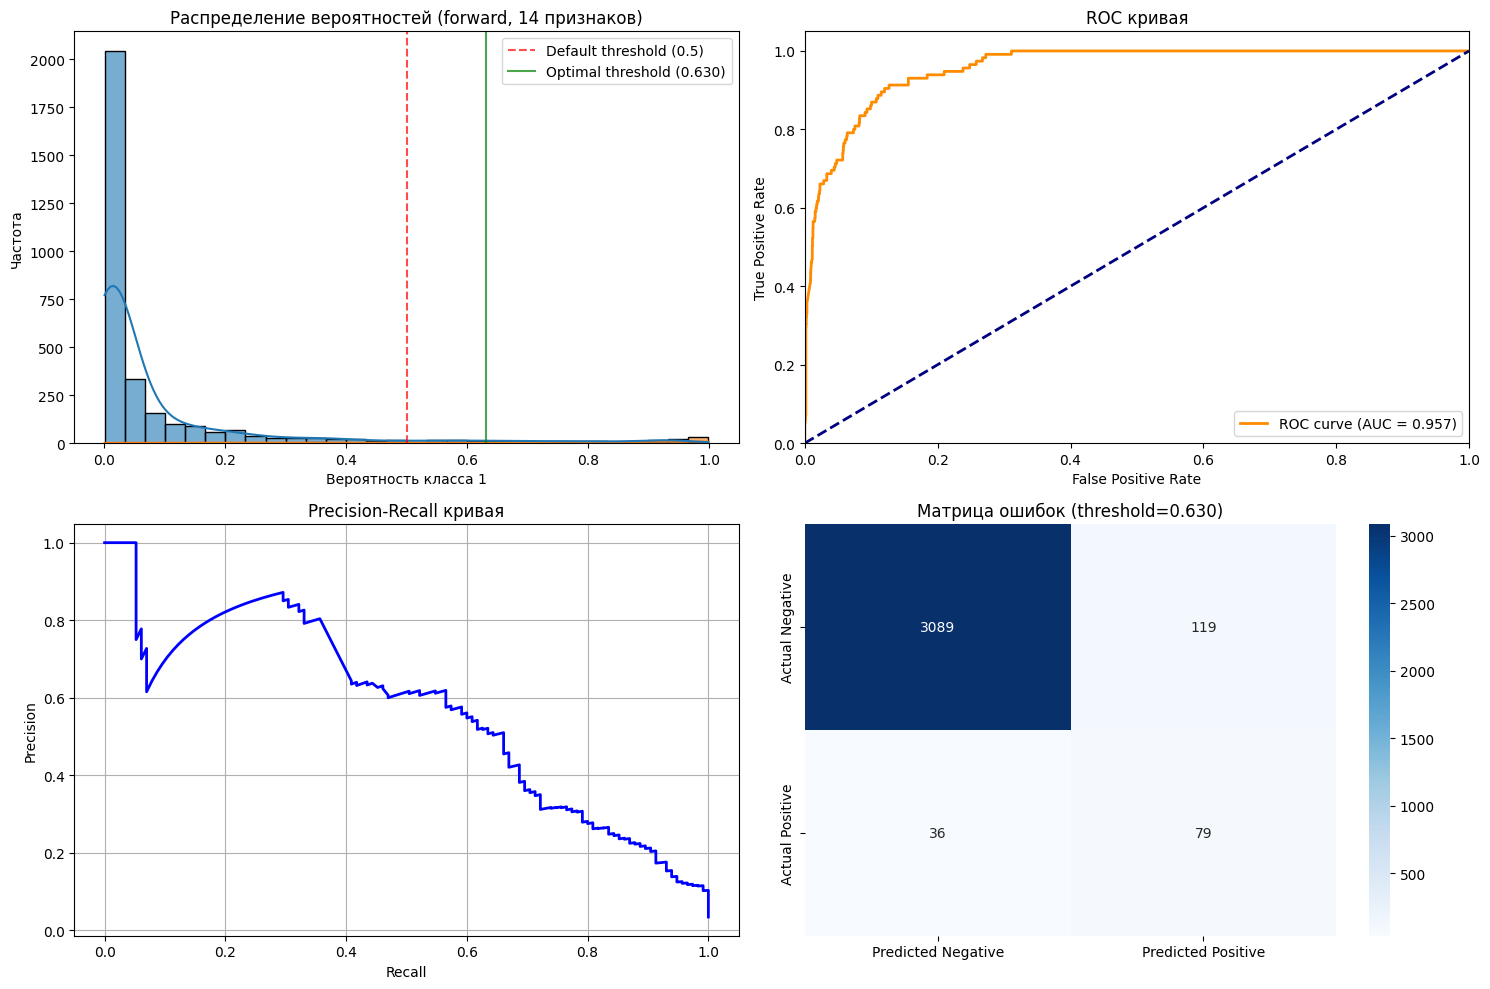

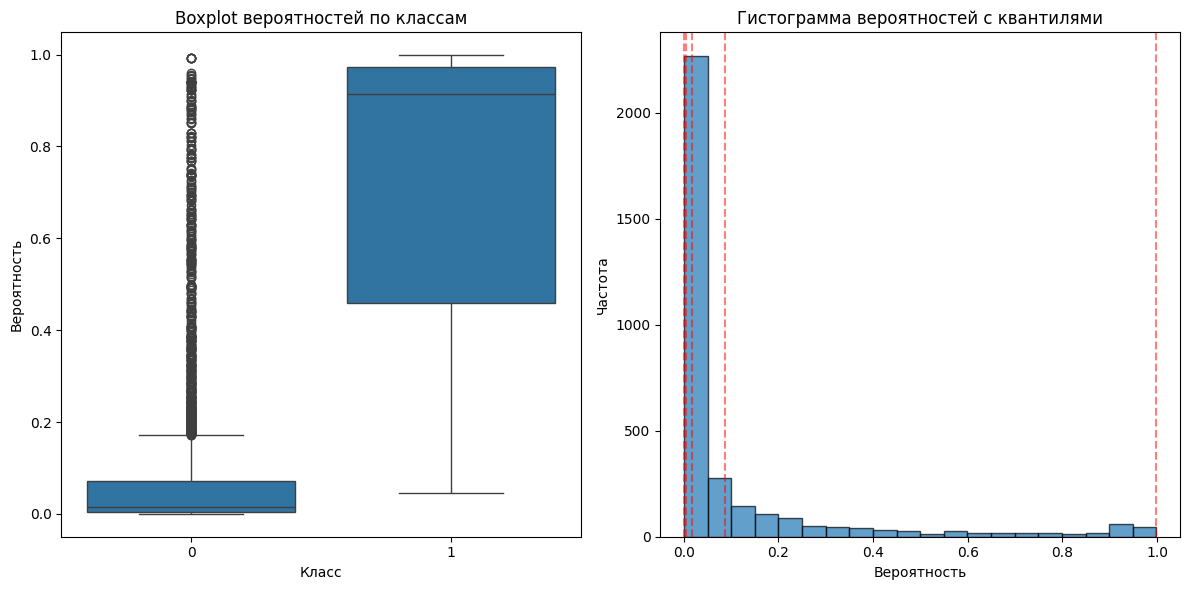

In [35]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


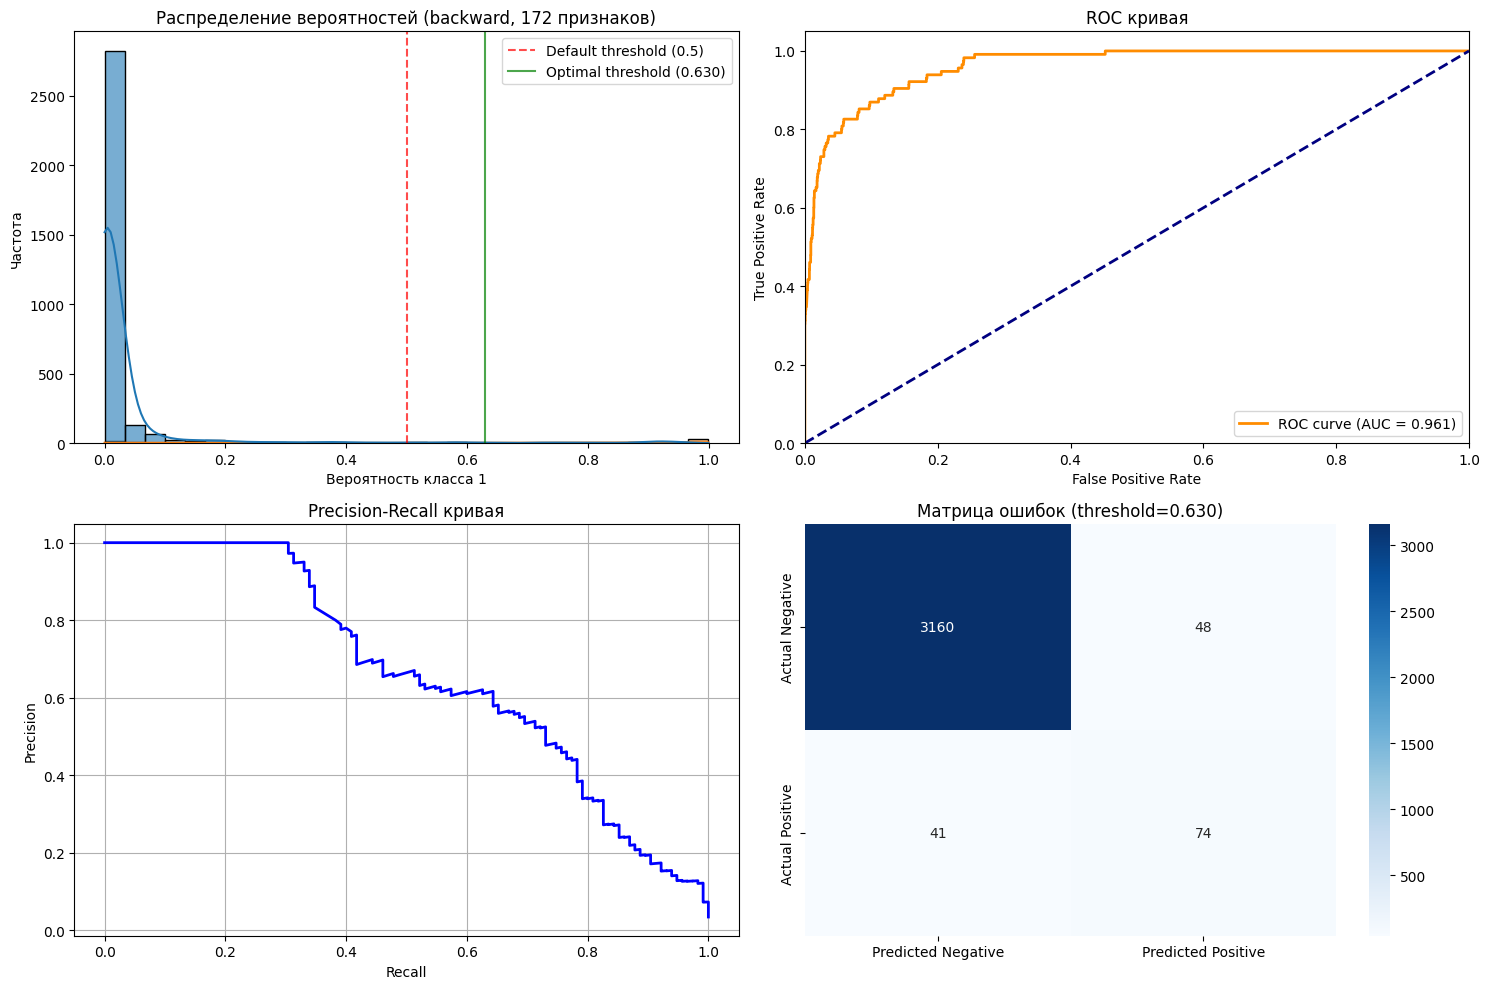

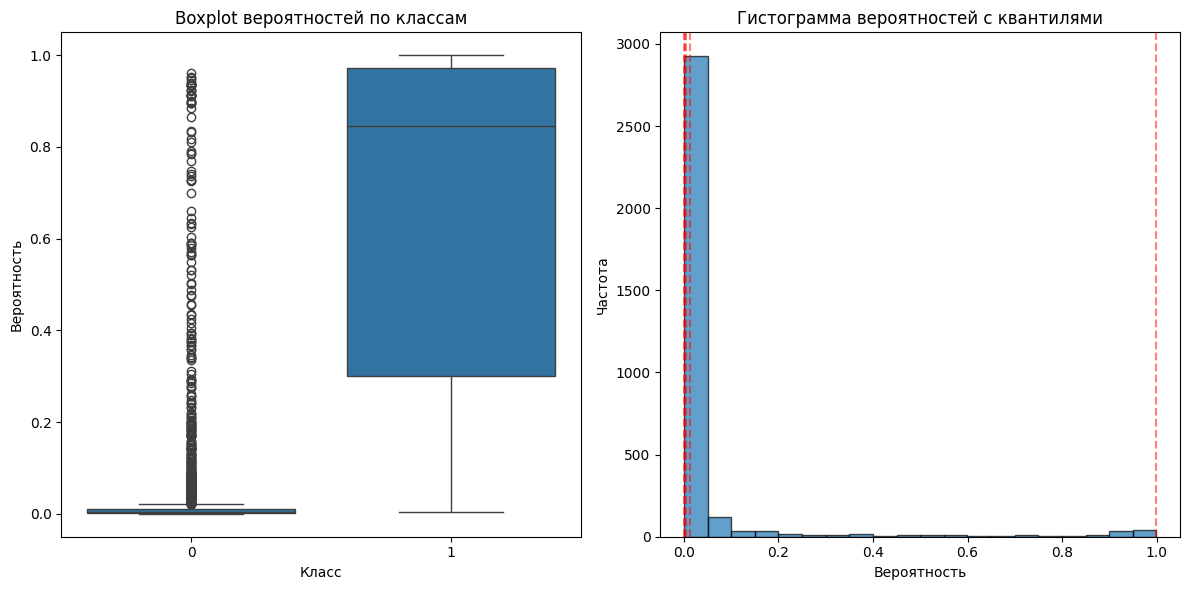

In [36]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [37]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 13
Лучшая f1: 0.4578
Признаки: ['Креатинин', 'UA_нестабильная_стенокардия', 'Нейтрофилы_абсолютное_значение', 'La2', 'Диастолического_АД_b', 'Геморрагический_инсульт_Выгрузка_из_ИБ_-_временный_столбец', 'Гемоглобин', 'Количество_пораженных_сосудов_Значимость', 'Стенокардия_в_диагнозе_при_поступлении', 'Продолжительность_операции', 'Калий_K', 'ФП_a_в_анамнезе', 'Лейкоциты']

Важность признаков:
  UA_нестабильная_стенокардия: 0.2617
  Нейтрофилы_абсолютное_значение: 0.1535
  Геморрагический_инсульт_Выгрузка_из_ИБ_-_временный_столбец: 0.1064
  Креатинин: 0.0777
  La2: 0.0603
  Стенокардия_в_диагнозе_при_поступлении: 0.0596
  Калий_K: 0.0590
  Гемоглобин: 0.0477
  ФП_a_в_анамнезе: 0.0458
  Диастолического_АД_b: 0.0389
  Количество_пораженных_сосудов_Значимость: 0.0361
  Лейкоциты: 0.0298
  Продолжительность_операции: 0.0235
=== Лучшие признаки (backward) ===
Количество признаков: 175
Лучшая 

In [38]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9560 с 13 признаками
Лучший ROC AUC (Backward): 0.9597 с 175 признаками
Оптимальный порог для бинарной классификации: 0.6300


In [39]:
analyzer = FeatureSelectionAnalyzer(X_clean, y, test_size=0.2, random_state=42, categorial_features=cat_features)

In [40]:
print("=== FORWARD SELECTION ===")
forward_features = analyzer.forward_selection(lgb_model, max_features=None, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== FORWARD SELECTION ===
Запуск Forward Selection...


  1%|          | 1/178 [00:09<27:26,  9.30s/it, roc_auc=0.7759, Features=1]

Step 1: Добавлен признак 'Креатинин', roc_auc: 0.7759


  1%|          | 2/178 [00:24<36:54, 12.58s/it, roc_auc=0.8464, Features=2]

Step 2: Добавлен признак 'UA_нестабильная_стенокардия', roc_auc: 0.8464


...

Step 14: Добавлен признак 'Недостаточность_митрального_клапана_степень', roc_auc: 0.9625


  8%|▊         | 15/178 [04:38<59:25, 21.88s/it, roc_auc=0.9626, Features=15]  

Step 15: Добавлен признак 'Холестерин_общий_b', roc_auc: 0.9626


  8%|▊         | 15/178 [05:02<54:46, 20.16s/it, roc_auc=0.9626, Features=15]

Step 16: Нет улучшений, останавливаемся
Forward Selection завершен. Выбрано признаков: 15


In [41]:
print("=== BACKWARD SELECTION ===")
forward_features = analyzer.backward_elimination(lgb_model, min_features=1, metric='roc_auc')  # ограничим до 10 признакей для демонстрации

=== BACKWARD SELECTION ===
Запуск Backward Elimination...


  1%|          | 1/177 [01:18<3:50:09, 78.46s/it, roc_auc=0.9634, Features=177]

Step 1: Удален признак 'UA_нестабильная_стенокардия', roc_auc: 0.9634


  1%|          | 2/177 [02:26<3:31:13, 72.42s/it, roc_auc=0.9671, Features=176]

Step 2: Удален признак 'АГ', roc_auc: 0.9671


...

Step 10: Удален признак 'Форма_ФП', roc_auc: 0.9697


  6%|▌         | 11/177 [11:51<2:50:11, 61.52s/it, roc_auc=0.9697, Features=167]

Step 11: Удален признак 'Хлор_Cl_b', roc_auc: 0.9697


  6%|▌         | 11/177 [12:50<3:13:53, 70.08s/it, roc_auc=0.9697, Features=167]

Step 12: Удаление ухудшает результат, останавливаемся
Backward Elimination завершен. Осталось признаков: 167



=== СРАВНЕНИЕ МЕТОДОВ ===


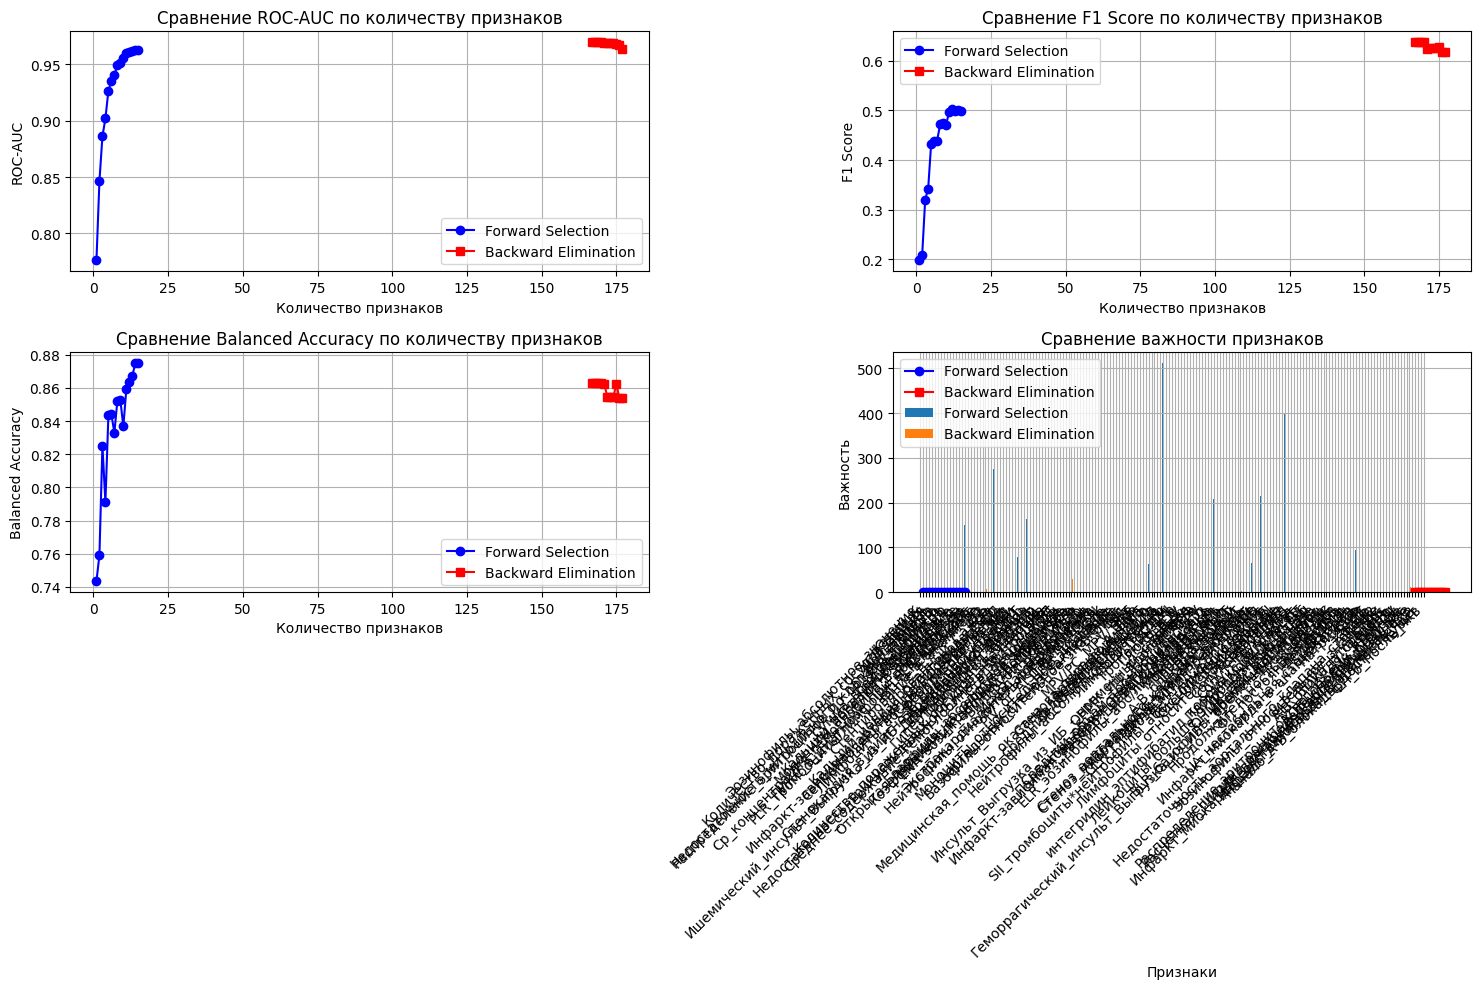

In [43]:
print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
analyzer.compare_feature_selection_methods()

In [44]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='forward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (forward, 15 признаков) ===
Лучший Threshold: 0.8900 (F1=0.6071)
По Youden's J: 0.2691


In [45]:
print("\n=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===")
best_threshold, _ = analyzer.find_optimal_threshold(method='backward')


=== ПОИСК ОПТИМАЛЬНОГО ПОРОГА ===
=== Оптимальные пороги (backward, 167 признаков) ===
Лучший Threshold: 0.6800 (F1=0.6751)
По Youden's J: 0.0440



=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


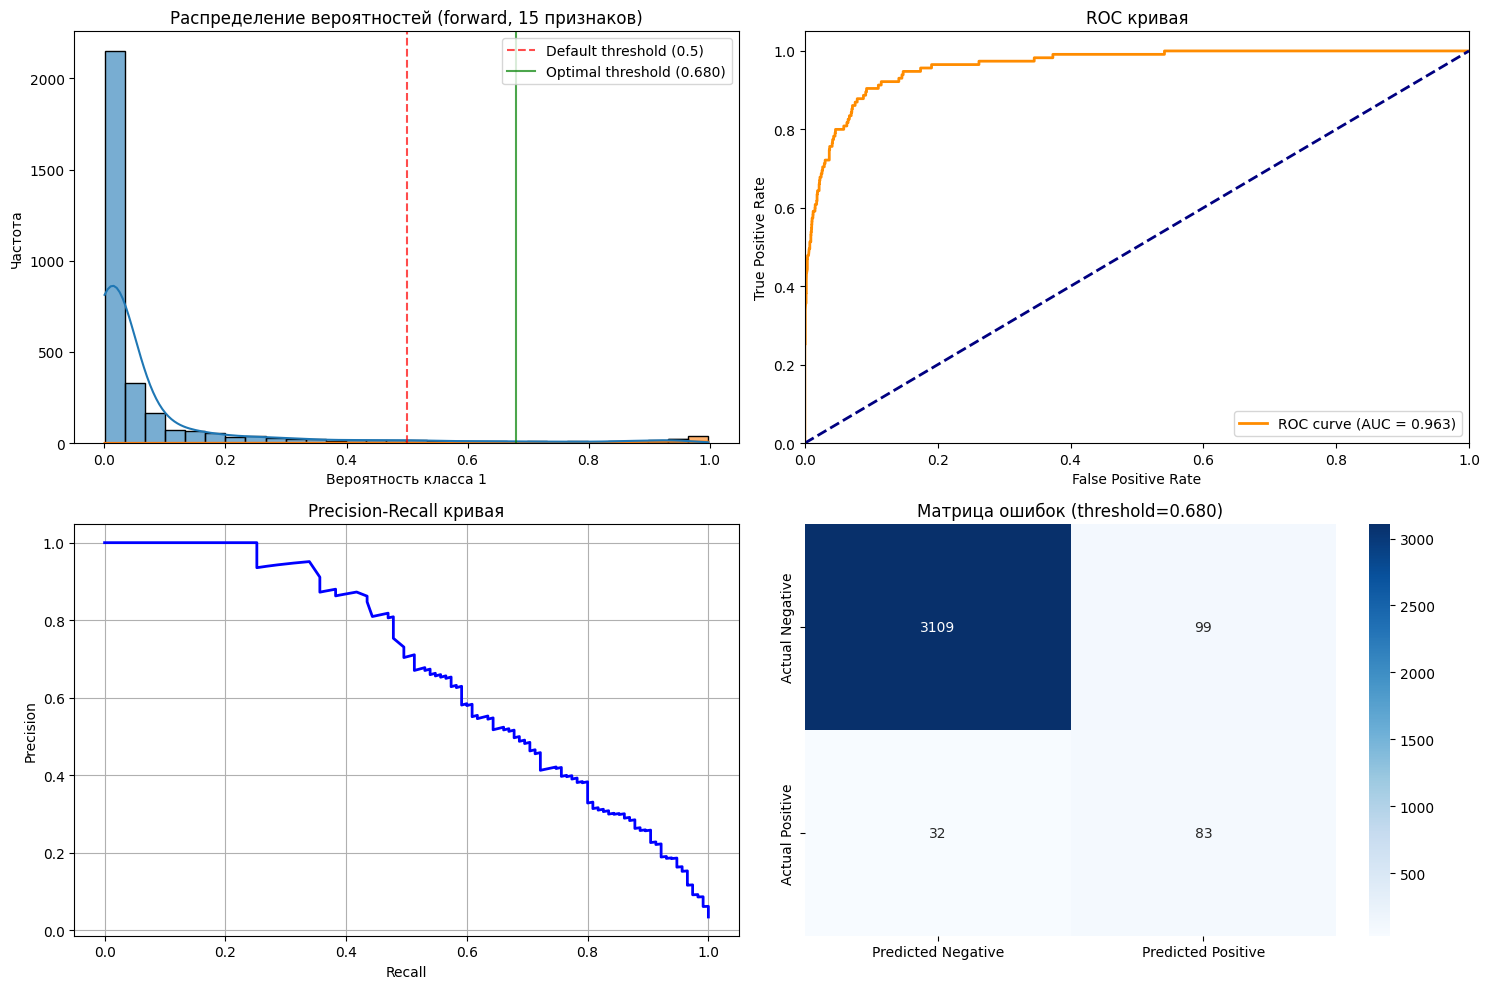

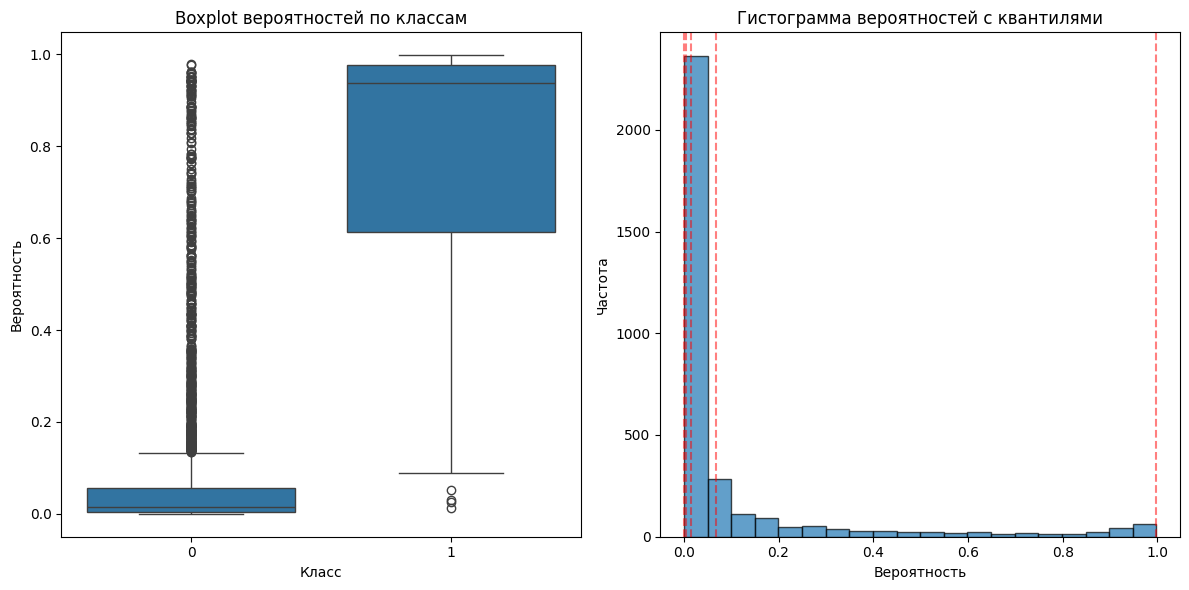

In [46]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='forward')


=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===


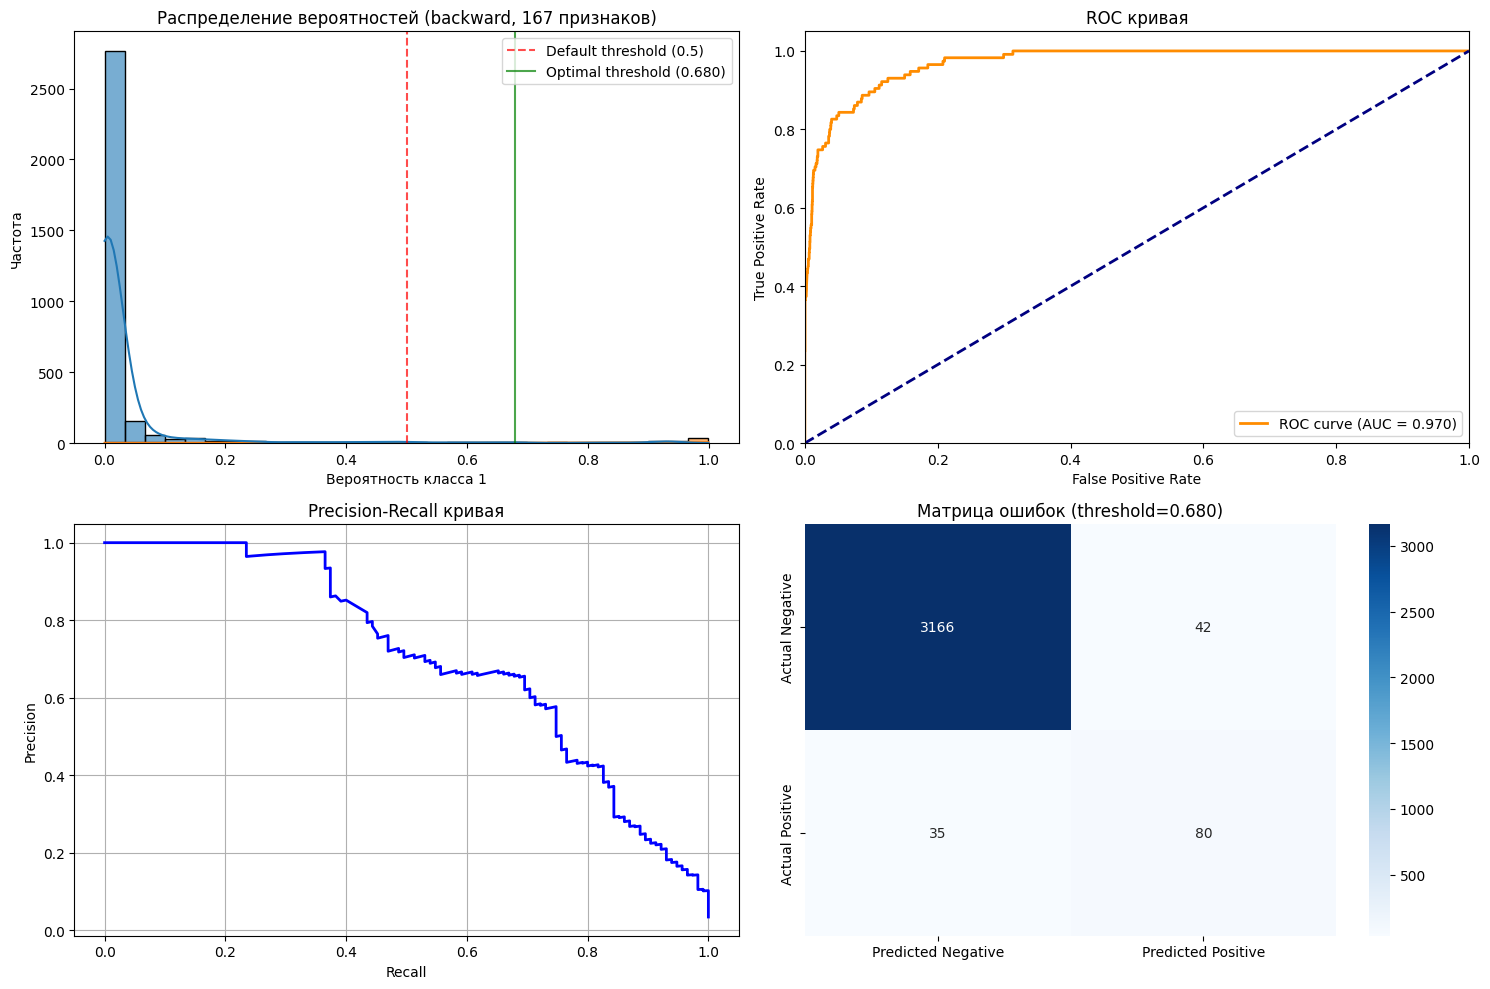

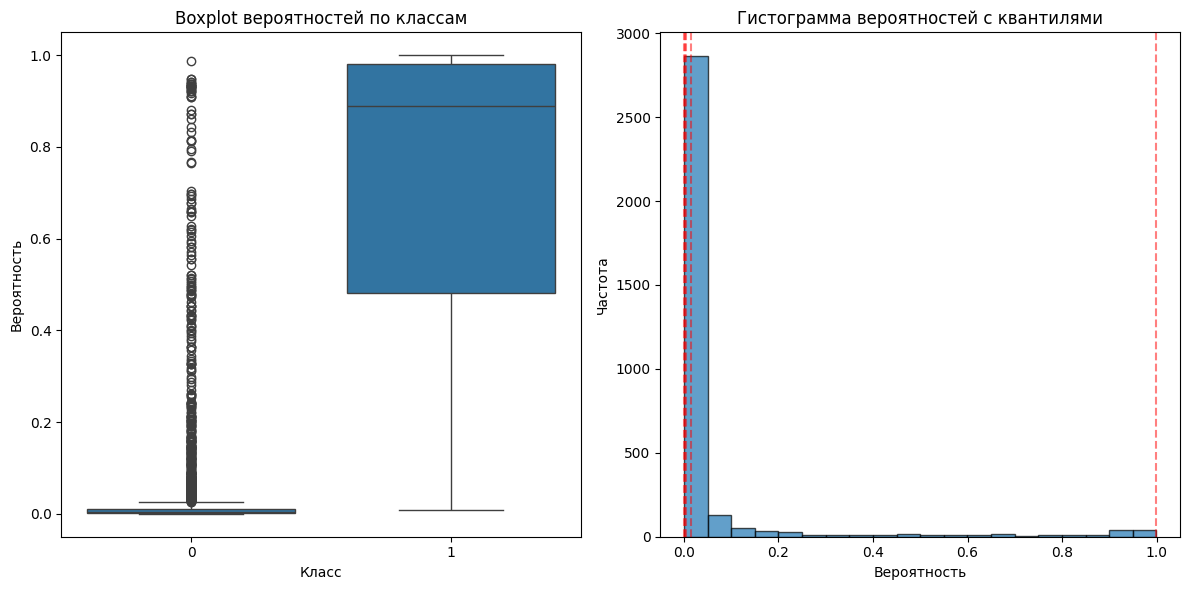

In [47]:
print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ВЕРОЯТНОСТЕЙ ===")
analyzer.visualize_probability_distribution(method='backward')

In [48]:
# Получение лучших признакей из всех комбинаций
print("\n=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===")
best_forward_features, best_forward_result = analyzer.get_best_features(method='forward')
best_backward_features, best_backward_result = analyzer.get_best_features(method='backward')


=== ЛУЧШИЕ ПРИЗНАКИ ИЗ ВСЕХ КОМБИНАЦИЙ ===
=== Лучшие признаки (forward) ===
Количество признаков: 12
Лучшая f1: 0.5028
Признаки: ['Креатинин', 'UA_нестабильная_стенокардия', 'Размер_правого_желудочка', 'Нейтрофилы_абсолютное_значение', 'MKB', 'Диастолического_АД_b', 'Age', 'Стенокардия_в_диагнозе_при_поступлении', 'Фибриноген', 'Стенокардия_форма_ИБ', 'Аортальный_стеноз_Градиент', 'Время_ЧКВ']

Важность признаков:
  Нейтрофилы_абсолютное_значение: 511.0000
  Креатинин: 399.0000
  Age: 275.0000
  MKB: 215.0000
  Размер_правого_желудочка: 209.0000
  Диастолического_АД_b: 164.0000
  Фибриноген: 149.0000
  UA_нестабильная_стенокардия: 93.0000
  Стенокардия_в_диагнозе_при_поступлении: 79.0000
  Аортальный_стеноз_Градиент: 65.0000
  Стенокардия_форма_ИБ: 62.0000
  Время_ЧКВ: 1.0000
=== Лучшие признаки (backward) ===
Количество признаков: 170
Лучшая f1: 0.6370
Признаки: ['Age', 'Sex', 'STEMI', 'ЧКВ', 'Вид_STEMI', 'Количество_пораженных_сосудов_Syntax', 'Количество_пораженных_сосудов_Значимо

In [49]:
print("\n=== ЗАКЛЮЧЕНИЕ ===")
print(f"Лучший ROC AUC (Forward): {best_forward_result['metrics']['roc_auc']:.4f} с {len(best_forward_features)} признаками")
print(f"Лучший ROC AUC (Backward): {best_backward_result['metrics']['roc_auc']:.4f} с {len(best_backward_features)} признаками")
print(f"Оптимальный порог для бинарной классификации: {best_threshold:.4f}")


=== ЗАКЛЮЧЕНИЕ ===
Лучший ROC AUC (Forward): 0.9607 с 12 признаками
Лучший ROC AUC (Backward): 0.9695 с 170 признаками
Оптимальный порог для бинарной классификации: 0.6800
